In [26]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier      # clasificador knn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix       # matriz de cnofusion

In [3]:
# cargar datos
data = pd.read_csv('star_classification.csv')

# Analisis expoloratorio del dataset

In [4]:
# visualizacion del dataset

# 1) imprimir columnas
columnas = data.columns.tolist()
print(columnas)

# 2) ver la cantidad total de columnas
print(f'cantidad de columnas: {len(data.columns)}')

# 3) ver las dimensiones del dataset
print(f'dimension del dataset (fila x columna): {data.shape}')

['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']
cantidad de columnas: 18
dimension del dataset (fila x columna): (100000, 18)


In [5]:
# 4) ver si hay nulos en el dataset
nulos = data.isnull().sum()
print(f'cantidad de nulos: {nulos}')

cantidad de nulos: obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [6]:
# 5) ver los tipos de cada columna para luego usar el clasificador
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

# EDA

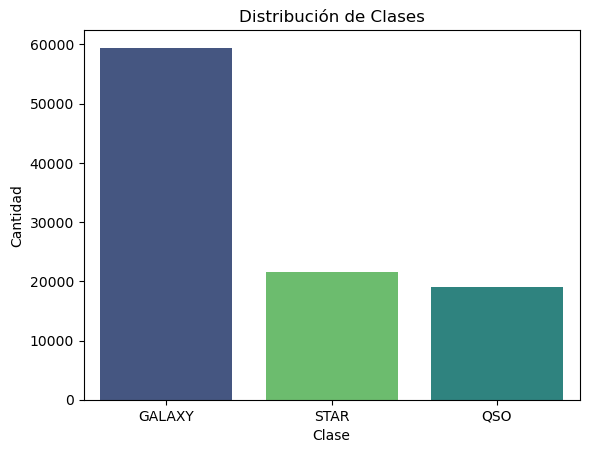

In [7]:
# ver la dstribucion entre las clases de los objetos astronomicos
sns.countplot(data=data, x='class', hue='class', legend=False, palette='viridis', order=data['class'].value_counts().index)
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

En base a este grafico se puede observar que la mayoria de los datos que hay son de Galaxias con casi 60 mil muestras, luego de Estrellas o de Quasares hay aproximadamente 20 mil de cada clase, por lo que el modelo tendra mas informacion sobre galaxias que las otras dos para poder entrenar.

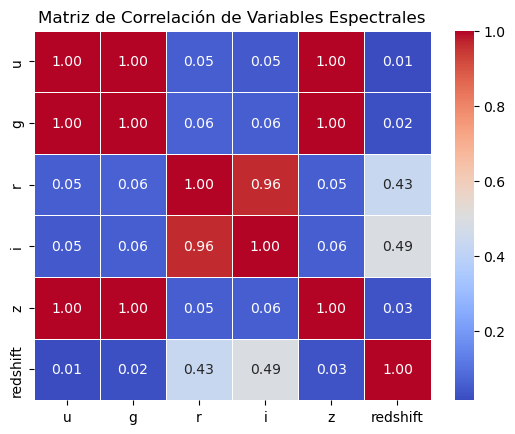

In [8]:
# Matriz de correlacion
caracteristicas = ['u', 'g', 'r', 'i', 'z', 'redshift']

matriz_corr = data[caracteristicas].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Espectrales')
plt.show()

Aca se puede apreciar que variables estan relacionadas entre si, mientras mas rojo y mas cerca del 1 mas relacionadas estan. Por ejemplo, se puede ver que los filtros de luz 'r' e 'i' tienen un 0.96 de relacion, son casi lo mismo para el modelo, en cambio, el redshift casi ni se relaciona con los filtros de luz y su indice es bajo.

# Clasificador

In [9]:
# Separar datos para predecir
caracteristicas = [      
                    'u',            #luz ultravioleta       
                    'g',            #luz verde
                    'r',            #luz roja       
                    'i',            #infrarrojo cercano       
                    'z',            #infrarrojo profundo           
                    'redshift'      #para ver que tan rapido se aleja el objeto
]

X = data[caracteristicas]
Y = data['class']

In [10]:
# division de datos para entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

### KNN

In [18]:
modelo = KNeighborsClassifier(n_neighbors=5)        # configurar el modelo
modelo.fit(X_train, y_train)                        #entrenar el modelo
predicciones = modelo.predict(X_test)           # preddecir las clases

In [28]:
# ver resultados de evaluacion
precision = accuracy_score(y_test, predicciones)
print(f"precision del modelo: {precision:.2f}")

print("\nMatriz de confusion:")
print(confusion_matrix(y_test, predicciones))

print("\nreporte de clasificacion:")
print(classification_report(y_test, predicciones))



precision del modelo: 0.95

Matriz de confusion:
[[11373   146   352]
 [  271  3540    10]
 [  172     8  4128]]

reporte de clasificacion:
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96     11871
         QSO       0.96      0.93      0.94      3821
        STAR       0.92      0.96      0.94      4308

    accuracy                           0.95     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.95      0.95      0.95     20000



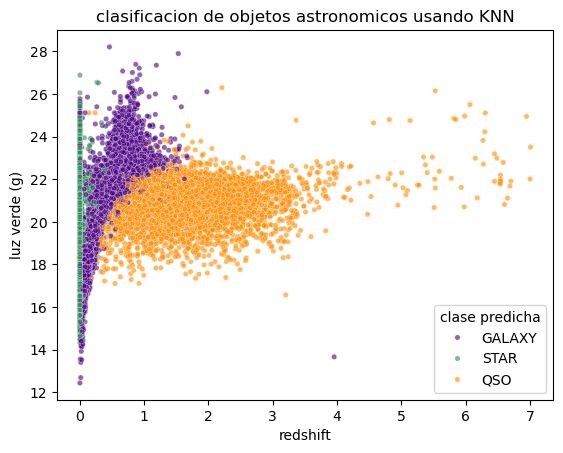

In [33]:
# scatter plot para ver la clasificacion de las clases

# se crea el grafio usando la variable redshift y g ya que son las mas representativas
sns.scatterplot(
    x=X_test['redshift'], 
    y=X_test['g'], 
    hue=predicciones,
    palette={'GALAXY': '#4B0082', 'QSO': '#FF8C00', 'STAR': '#2E8B57'},
    alpha=0.6, 
    s=15      
)

plt.title('clasificacion de objetos astronomicos usando KNN')
plt.xlabel('redshift')
plt.ylabel('luz verde (g)')
plt.legend(title='clase predicha')
plt.show()